In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings 
warnings.filterwarnings('ignore')

sns.set_theme(style = 'whitegrid', font_scale = 1.1)

In [3]:
df = pd.read_csv('data/processed/spotify_clean.csv')
X = df.drop('track_genre', axis = 1)
y_raw = df['track_genre']

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f"Train: {X_train.shape[0]} треков | Test: {X_test.shape[0]} треков")
print(f"Классы: {class_names}")


Train: 7989 треков | Test: 1998 треков
Классы: ['acoustic' 'afrobeat' 'alt-rock' 'ambient' 'bluegrass' 'cantopop'
 'chicago-house' 'disney' 'forro' 'tango']


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000, random_state = 42),
    'Random Forest': RandomForestClassifier(n_estimators = 150, random_state = 42),
    'KNN': KNeighborsClassifier(n_neighbors = 7),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 150, random_state = 42)
}

In [6]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average = 'macro')

    results[name] = {'acc': acc, 'f1': f1, 'model': model, 'preds': y_pred}
    print(f"{name} | Accuracy: {acc:.4f} | F1-Macro: {f1:.4f}")

Logistic Regression | Accuracy: 0.5981 | F1-Macro: 0.5937
Random Forest | Accuracy: 0.7733 | F1-Macro: 0.7715
KNN | Accuracy: 0.6757 | F1-Macro: 0.6737
Gradient Boosting | Accuracy: 0.7683 | F1-Macro: 0.7680


In [7]:
from sklearn.model_selection import cross_val_score
print('Считаем стабильные метрики через CV')

cv_results = {}

for name, model in models.items():
    acc_cv = cross_val_score(model, X_train_scaled, y_train, cv = 5, scoring = 'accuracy')
    f1_cv = cross_val_score(model, X_train_scaled, y_train, cv = 5, scoring = 'f1_macro')

    cv_results[name] = {
    'acc': acc_cv.mean(),
    'f1': f1_cv.mean(),
    'acc_std': acc_cv.std(),
    'f1_std': f1_cv.std()
    }

    print(f"{name}: Accuracy = {acc_cv.mean():.4f}+-{acc_cv.std():.3f} | F1 = {f1_cv.mean():.4f}+-{f1_cv.std():.3f} ")

df_metrics = pd.DataFrame(cv_results).T[['acc', 'f1']].reset_index()
df_metrics.columns = ['Model', 'Accuracy', 'F1_Macro']

Считаем стабильные метрики через CV
Logistic Regression: Accuracy = 0.6107+-0.006 | F1 = 0.6062+-0.006 
Random Forest: Accuracy = 0.7733+-0.010 | F1 = 0.7712+-0.010 
KNN: Accuracy = 0.6838+-0.010 | F1 = 0.6818+-0.010 
Gradient Boosting: Accuracy = 0.7642+-0.011 | F1 = 0.7637+-0.011 


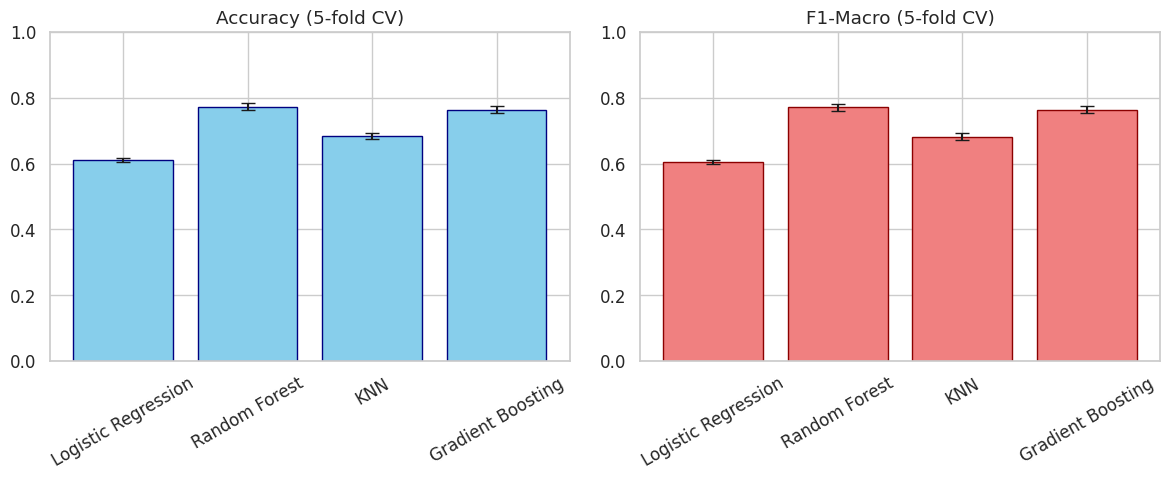

In [8]:
df_cv = pd.DataFrame(cv_results).T[['acc', 'f1', 'acc_std', 'f1_std']].reset_index()
df_cv.columns = ['Model', 'Accuracy', 'F1-Macro', 'Acc_Std', 'F1_Std']

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].bar(df_cv['Model'], df_cv['Accuracy'], yerr=df_cv['Acc_Std'], 
            capsize=5, color='skyblue', edgecolor='navy')
axes[0].set_title('Accuracy (5-fold CV)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)

axes[1].bar(df_cv['Model'], df_cv['F1-Macro'], yerr=df_cv['F1_Std'], 
            capsize=5, color='lightcoral', edgecolor='darkred')
axes[1].set_title('F1-Macro (5-fold CV)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [9]:
best_model_name = df_cv.loc[df_cv['F1-Macro'].idxmax(), 'Model']
print(f"Лучшая модель по кросс-валидации: {best_model_name}")

from sklearn.model_selection import GridSearchCV

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 150],
        'max_depth': [10,15, None],
        'min_samples_split': [2, 5]
    }
    best_model = RandomForestClassifier(random_state = 42)

elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10], 
        'solver': ['lbfgs', 'saga'],
        'max_iter': [1000]
    }
    best_model = LogisticRegression(random_state = 42)

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
    best_model = GradientBoostingClassifier(random_state = 42)
else:
    param_grid = {
        'n_neighbors': [5, 7, 9],
        'weights': ['uniform', 'distance']
    }
    best_model = KNeighborsClassifier()

print(f"Запускаем GridSearch для {best_model_name}...")
grid = GridSearchCV(best_model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"F1 на валидации: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Лучшая модель по кросс-валидации: Random Forest
Запускаем GridSearch для Random Forest...
Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
F1 на валидации: 0.7656


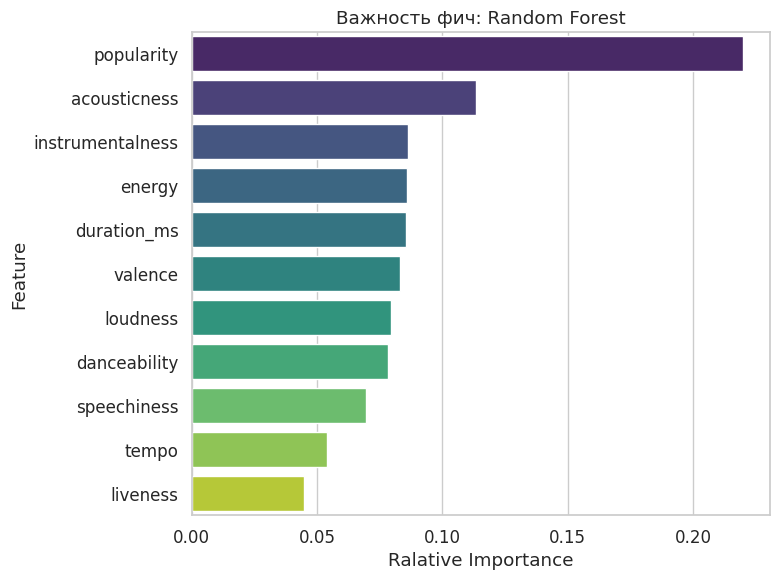

Топ-5 самых важных признаков для классификации:
popularity: 0.2198
acousticness: 0.1134
instrumentalness: 0.0863
energy: 0.0860
duration_ms: 0.0854

Финальная модель: Random Forest
Лучший F1-Macro на кросс-валидации: 0.7656


In [10]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending = False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Важность фич: {best_model_name}')
    plt.xlabel('Ralative Importance')
    plt.tight_layout()
    plt.show()

    print("Топ-5 самых важных признаков для классификации:")
    for _, row in feat_imp.head().iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")
else:
    print("У этой модели нет .feature_importances_ (LogReg или KNN).")
    print("Для линейных моделей можно смотреть коэффициенты (.coef_), для KNN — permutation importance.")

print(f"\nФинальная модель: {best_model_name}")
print(f"Лучший F1-Macro на кросс-валидации: {grid.best_score_:.4f}")

In [11]:
import joblib
import os

os.makedirs('models', exist_ok = True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

print('Артефакты сохранены в models/: best_model.pkl, scaler.pkl, label_encoder.pkl')

# функция предсказания 

def predict_genre(**features_dict):
    model = joblib.load('models/best_model.pkl')
    scaler = joblib.load('models/scaler.pkl')
    le = joblib.load('models/label_encoder.pkl')

    input_df = pd.DataFrame([features_dict]).reindex(columns=X.columns, fill_value = 0.0)

    input_scaled = scaler.transform(input_df)
    probas = model.predict_proba(input_scaled)[0]

    top_3_idx = np.argsort(probas)[::-1][:3]
    top_3 = [(le.inverse_transform([i])[0], round(probas[i] * 100, 1)) for i in top_3_idx]
    return top_3

print('Тест функции:')
print('Энергичный танцевальный трек:')
print(predict_genre(danceability = 0.85, energy = 0.9, valence = 0.7, tempo = 128, popularity = 85))
print('Медленный акустический трек:')
print(predict_genre(danceability = 0.3, energy = 0.2, valence = 0.4, tempo = 75, popularity = 30, acousticness = 0.85))

Артефакты сохранены в models/: best_model.pkl, scaler.pkl, label_encoder.pkl
Тест функции:
Энергичный танцевальный трек:
[('alt-rock', np.float64(38.0)), ('forro', np.float64(22.7)), ('acoustic', np.float64(14.0))]
Медленный акустический трек:
[('disney', np.float64(40.0)), ('acoustic', np.float64(20.0)), ('bluegrass', np.float64(14.0))]


In [ ]:
# Анализ ошибок
y_pred = best_model.predict(X_test_scaled)
